In [1]:
# Import the libraries
import os
import random
import numpy as np
from math import sqrt
from ase.io import read
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist

In [2]:
# Import the global SOAP descriptor of DFT Li3PS4 dataset
soap_descriptor_DFT_Li3PS4_dataset = np.load("DFT_Li3PS4_outer_average_SOAP_16000.npy")
print(soap_descriptor_DFT_Li3PS4_dataset.shape)

(16000, 390)


In [3]:
# Transform high dimensional SOAP into 2D PCA 
pca = PCA(n_components=2)
pca.fit(soap_descriptor_DFT_Li3PS4_dataset)
pca_transformed = pca.transform(soap_descriptor_DFT_Li3PS4_dataset)
 
# Check Explained variance ratio for each component
explained_variance_ratio = pca.explained_variance_ratio_

# Check Cumulative explained variance
cumulative_variance = np.cumsum(explained_variance_ratio)

print("Explained variance ratio:", explained_variance_ratio)
print("Cumulative explained variance:", cumulative_variance)

Explained variance ratio: [0.69647423 0.10530895]
Cumulative explained variance: [0.69647423 0.80178318]


In [4]:
#Calculate the euclidean distances between each sample's 2D PCA representation
distance_matrix = cdist(pca_transformed, pca_transformed, metric='euclidean')

In [5]:
# Data-selection with Farthest Point Sampling
def greedy_farthest_point_sampling(distance_matrix, num_samples):
    """
    Perform greedy farthest point sampling on a distance matrix.

    Args:
        distance_matrix (numpy.ndarray): Pairwise distance matrix (n x n).
        num_samples (int): Number of points to sample.

    Returns:
        list: Indices of the sampled points.
    """
    num_points = distance_matrix.shape[0]
    selected_points = [np.random.randint(num_points)]  # Start with a random point
    min_distances = np.full(num_points, np.inf)  # Initialize minimum distances to infinity

    for _ in range(1, num_samples):
        # Update the minimum distance to selected points
        for i in range(num_points):
            min_distances[i] = min(min_distances[i], distance_matrix[i, selected_points[-1]])
        
        # Find the point with the maximum minimum distance
        next_point = np.argmax(min_distances)
        selected_points.append(next_point)

    return selected_points


num_samples = 13000 # Number of training data to select
selected_data_indices = greedy_farthest_point_sampling(distance_matrix, num_samples)

In [6]:
# Extract the training data using the indices
training_pca = [pca_transformed[indice] for indice in selected_data_indices]
training_pca = np.array(training_pca)  # Convert to NumPy array for easy indexing

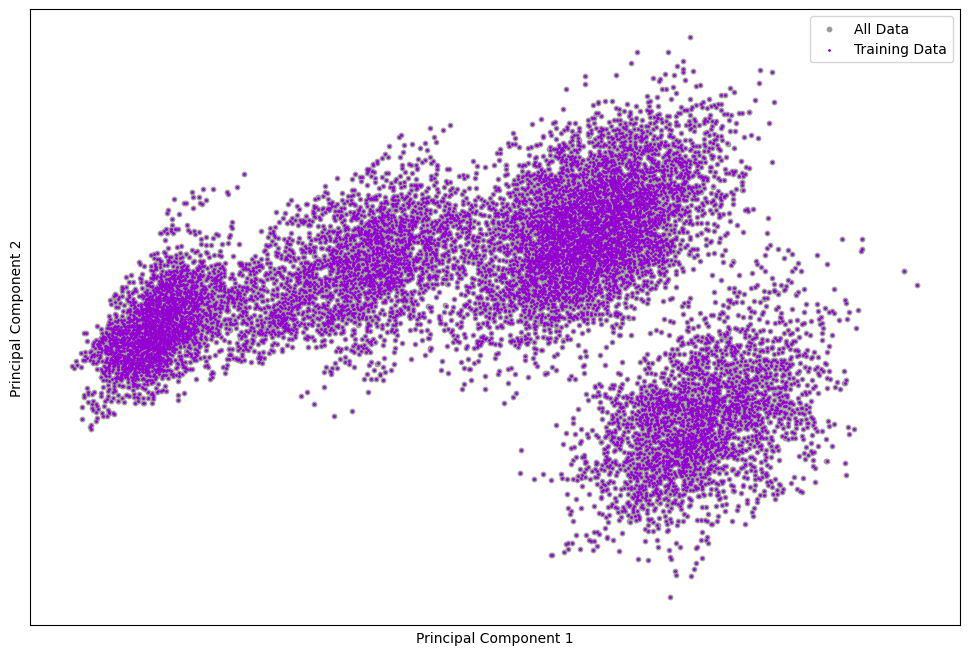

In [7]:
# Plot the data for the first two principal components
plt.figure(figsize=(12,8))
plt.scatter(pca_transformed[:, 0], pca_transformed[:, 1], c='#9C9A9D', marker='o',s=10,label="All Data")
plt.scatter(training_pca[:, 0], training_pca[:, 1], c='darkviolet', marker='o',s=1,label="Training Data")
plt.xlabel('Principal Component 1',fontsize=10)
plt.ylabel('Principal Component 2',fontsize=10)
plt.legend(fontsize=10)
plt.grid(True)
plt.xticks([])
plt.yticks([])
plt.show()

In [8]:
all_numbers = list(range(16000))
training_list_indices = selected_data_indices
remaining_numbers = [num for num in all_numbers if num not in training_list_indices]
# Select 800 validation samples from the remaining data after training data selection
validation_size = 800
validation_indices = random.sample(remaining_numbers, k=validation_size)
# All the remaining held out non training non validation data is used for testing
testing_indices = [num for num in remaining_numbers if num not in validation_indices]
print("Num training indices:", len(training_list_indices))
print("Num validation indices:", len(validation_indices))
print("Num testing indices:", len(testing_indices))

Num training indices: 13000
Num validation indices: 800
Num testing indices: 2200


In [9]:
datadir = "DFT_Li3PS4_Divided" # Data directory where each configuration is divided into separate xyz file

output_file = "FPS_"+str(len(training_list_indices))+"_DFT_Li3PS4_training_samples.xyz" # Name of the training data file

output_filepath = os.path.join("Output_Data_Folder", output_file) # Output directory to store training data file

# Open the output file in write mode
with open(output_filepath, 'w') as outfile:
    # Iterate over each index in training_list_indices
    for idx in training_list_indices:
        # Increment index by 1 to match filename format
        idx += 1
        # Construct the filename for the current index
        filename = f"testing{idx}.xyz"
        # Construct the full path of the file
        filepath = os.path.join(datadir, filename)
        # Check if the file exists
        if os.path.exists(filepath):
            # Open the current file in read mode
            with open(filepath, 'r') as infile:
                # Read the contents of the current file
                contents = infile.read()
                # Write the contents to the output file
                outfile.write(contents)
                # Add a newline character to separate entries
                #outfile.write('\n')
        else:
            print(f"File {filename} does not exist.")

print("Merged XYZ file created successfully.")

Merged XYZ file created successfully.


In [10]:
datadir = "DFT_Li3PS4_Divided" # Data directory where each configuration is divided into separate xyz file

output_file = "FPS_"+str(len(training_list_indices))+"_DFT_Li3PS4_validation_samples.xyz" # Name of the validation data file

output_filepath = os.path.join("Output_Data_Folder", output_file) # Output directory to store validation data file

# Open the output file in write mode
with open(output_filepath, 'w') as outfile:
    # Iterate over each index in training_list_indices
    for idx in validation_indices:
        # Increment index by 1 to match filename format
        idx += 1
        # Construct the filename for the current index
        filename = f"testing{idx}.xyz"
        # Construct the full path of the file
        filepath = os.path.join(datadir, filename)
        # Check if the file exists
        if os.path.exists(filepath):
            # Open the current file in read mode
            with open(filepath, 'r') as infile:
                # Read the contents of the current file
                contents = infile.read()
                # Write the contents to the output file
                outfile.write(contents)
                # Add a newline character to separate entries
                #outfile.write('\n')
        else:
            print(f"File {filename} does not exist.")

print("Merged XYZ file created successfully.")

Merged XYZ file created successfully.


In [11]:
datadir = "DFT_Li3PS4_Divided" # Data directory where each configuration is divided into separate xyz file

output_file = "FPS_"+str(len(training_list_indices))+"_DFT_Li3PS4_testing_samples.xyz" # Name of the testing data file

output_filepath = os.path.join("Output_Data_Folder", output_file) # Output directory to store testing data file

# Open the output file in write mode
with open(output_filepath, 'w') as outfile:
    # Iterate over each index in training_list_indices
    for idx in testing_indices:
        # Increment index by 1 to match filename format
        idx += 1
        # Construct the filename for the current index
        filename = f"testing{idx}.xyz"
        # Construct the full path of the file
        filepath = os.path.join(datadir, filename)
        # Check if the file exists
        if os.path.exists(filepath):
            # Open the current file in read mode
            with open(filepath, 'r') as infile:
                # Read the contents of the current file
                contents = infile.read()
                # Write the contents to the output file
                outfile.write(contents)
                # Add a newline character to separate entries
                #outfile.write('\n')
        else:
            print(f"File {filename} does not exist.")

print("Merged XYZ file created successfully.")

Merged XYZ file created successfully.


In [12]:
datadir = "Output_Data_Folder" # Output directory to store training+validation+testing merged data file

output_file = "FPS_"+str(len(training_list_indices))+"_DFT_Li3PS4_train_valid_test_samples_merged.xyz" # Name of the training+validation+testing merged data file

output_filepath = os.path.join("Output_Data_Folder", output_file) # Output directory to store training+validation+testing merged data file

mylist = [f"FPS_"+str(len(training_list_indices))+"_DFT_Li3PS4_training_samples.xyz",
          f"FPS_"+str(len(training_list_indices))+"_DFT_Li3PS4_validation_samples.xyz",
        f"FPS_"+str(len(training_list_indices))+"_DFT_Li3PS4_testing_samples.xyz"]

# Open the output file in write mode
with open(output_filepath, 'w') as outfile:
    # Iterate over each index in training_list_indices
    for idx in mylist:
        # Increment index by 1 to match filename format
 
        # Construct the filename for the current index
        filename = idx
        # Construct the full path of the file
        filepath = os.path.join(datadir, filename)
        # Check if the file exists
        if os.path.exists(filepath):
            # Open the current file in read mode
            with open(filepath, 'r') as infile:
                # Read the contents of the current file
                contents = infile.read()
                # Write the contents to the output file
                outfile.write(contents)
                # Add a newline character to separate entries
                #outfile.write('\n')
        else:
            print(f"File {filename} does not exist.")

print("Merged XYZ file created successfully.")

Merged XYZ file created successfully.


In [13]:
# Check if the number of configurations in the merged data file is equal to total number of data
# This is a verification step to verify the correctnes of data-selection process
def count_configurations_in_xyz(file_path):
    try:
        # Read all configurations from the xyz file
        configurations = read(file_path, index=':')
        
        # Count the number of configurations
        num_configurations = len(configurations)
        
        return num_configurations
    except Exception as e:
        print(f"An error occurred: {e}")
        return None


if __name__ == "__main__":
    filename_list = [output_file]
    for file_path in filename_list:
        file_path = "Output_Data_Folder/" + file_path
        num_configurations = count_configurations_in_xyz(file_path)
        
        if num_configurations is not None:
            print(f"The number of configurations in the merged is: {num_configurations}")

The number of configurations in the merged is: 16000
